In [2]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors

ROOT = "/scratch/sleonard/routing_decision"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

In [3]:
def get_thresholds(dag: dict, target: str, quantiles: list) -> list: 
    matrix = dag[target]
    N_LAYERS = matrix.shape[0]

    # Create a mask for forward edges (Layer S < Layer R)
    # This ensures we don't include invalid backward connections in our distribution
    s_idx = torch.arange(N_LAYERS).view(-1, 1, 1, 1)
    r_idx = torch.arange(N_LAYERS).view(1, 1, -1, 1)
    mask = (s_idx < r_idx).expand_as(matrix)    
    # Flatten valid weights
    valid_weights = torch.abs(matrix[mask].float())
    valid_weights = valid_weights[valid_weights > 1e-9]

    # Calculate all quantiles at once
    q_tensor = torch.tensor(quantiles, device=valid_weights.device)
    thresholds = torch.quantile(valid_weights, q_tensor)
    
    # Return a dictionary mapping quantile -> threshold
    return dict(zip(quantiles, thresholds.tolist()))


def tresholding_routing_graph(dag: dict, target: str, threshold: float) -> ig.Graph:
    # Get the 4D matrix (Shape: [16, 64, 16, 64])
    matrix = dag[target]
    N_LAYERS, N_EXPERTS = matrix.shape[0], matrix.shape[1]
    N_NODES = N_LAYERS * N_EXPERTS

    # Find where the weights are above the threshold
    s_layers, s_exps, r_layers, r_exps = np.where(np.abs(matrix) > threshold) 

    # Convert those coordinates into Vertex IDs
    senders = s_layers * N_EXPERTS + s_exps
    receivers = r_layers * N_EXPERTS + r_exps

    # Extract the weights for these specific edges
    weights = matrix[s_layers, s_exps, r_layers, r_exps]

    # Build the graph
    g = ig.Graph(directed=True, n=N_NODES)
    
    # zip pairs them up: [(s1, r1), (s2, r2), ...]
    edges = list(zip(senders.tolist(), receivers.tolist()))
    g.add_edges(edges)
    
    # Assign the weights and metadata
    g.es["weight"] = weights.tolist()
    g.vs["layer"] = [v // N_EXPERTS for v in range(N_NODES)]
    g.vs["expert"] = [v % N_EXPERTS for v in range(N_NODES)]

    return g

In [4]:
def max_path_length(g: ig.Graph) -> tuple[list[int], int, int]:
    n = len(g.vs)
    in_degree = g.indegree() 
    dp = [0] * n            # Longest distance from any source to node i
    predecessor = [-1] * n  # predecessors for backtracking
    count = [0] * n         # Number of ways to reach node i with distance dp[i]
    
    # 1. Initialize sources (nodes with no incoming edges)
    sources = [i for i, d in enumerate(in_degree) if d == 0]
    for s in sources:
        count[s] = 1 # Each source starts 1 path of length 0
    
    queue = deque(sources)
    
    while queue:
        curr = queue.popleft()
        
        for neighbor in g.neighbors(curr, mode="out"):
            new_dist = dp[curr] + 1
            
            if new_dist > dp[neighbor]:
                # Found a strictly better path
                dp[neighbor] = new_dist
                predecessor[neighbor] = curr
                count[neighbor] = count[curr] # Reset count to parent's count
            elif new_dist == dp[neighbor]:
                # Found an alternative path of the same max length
                count[neighbor] += count[curr]
            
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)
    
    # 3. Identify the Global Maximum
    max_val = max(dp)
    
    # 4. Backtrack to find ONE sample path
    # We pick the FIRST node that reached the max_val to start backtracking
    end_node = dp.index(max_val)
    path = []
    curr_trace = end_node
    while curr_trace != -1:
        path.append(curr_trace)
        curr_trace = predecessor[curr_trace]
    
    # 5. Calculate total paths of length max_val
    # Multiple nodes could end at the same max depth (e.g., different experts in Layer 15)
    total_paths = sum(count[i] for i in range(n) if dp[i] == max_val)
    
    return path[::-1], max_val, total_paths

def path_as_str(path: list) -> str: 
    expert_path = []
    for curr_node in path: 
        layer = curr_node // 64
        expert = curr_node % 64
        expert_path.append(f"M{layer}E{expert}")
    
    return " -> ".join(expert_path)

In [ ]:
def show_enhanced_layered_graph(g, quantile: float, target: str, dataset: str, n_prompts: int) -> None:
    edge_list = g.get_edgelist()
    if not edge_list:
        print("No edges found to plot!")
        return
        
    # Get signed values for the title
    raw_weights = g.es["weight"]
    max_w = max(raw_weights)
    min_w = min(raw_weights)
    
    # Absolute values for visual scaling
    abs_weights = [abs(w) for w in raw_weights]
    max_mag, min_mag = max(abs_weights), min(abs_weights)

    # --- SPARSITY CALCULATIONS ---
    N_LAYERS, N_EXPERTS = 16, 64
    TOTAL_POSSIBLE_NODES = N_LAYERS * N_EXPERTS
    # Max possible edges in a layered DAG (Layer i to Layer >i)
    # Total edges = Sum_{i=0 to 14} (N_EXPERTS * (15-i) * N_EXPERTS)
    TOTAL_POSSIBLE_EDGES = sum(N_EXPERTS * ( (N_LAYERS - 1 - i) * N_EXPERTS ) for i in range(N_LAYERS-1))
    
    n_active_nodes = g.vcount() # Note: igraph 'n' in the thresholding function was TOTAL_POSSIBLE_NODES
    # Better: count nodes that actually have degree > 0
    active_node_indices = [v.index for v in g.vs if v.degree() > 0]
    n_nodes_used = len(active_node_indices)
    n_edges_used = g.ecount()
    
    node_sparsity = (n_nodes_used / TOTAL_POSSIBLE_NODES) * 100
    edge_sparsity = (n_edges_used / TOTAL_POSSIBLE_EDGES) * 100

    # 1. Build NetworkX Graph
    G = nx.DiGraph()
    pos, labels = {}, {}
    
    X_SPACING, Y_SPACING = 250, 150
    for node_idx in active_node_indices:
        layer, expert_idx = node_idx // N_EXPERTS, node_idx % N_EXPERTS
        pos[node_idx] = (expert_idx * X_SPACING, -layer * Y_SPACING)
        labels[node_idx] = f"M{layer}\nE{expert_idx}"
        G.add_node(node_idx)

    # --- COLOR LOGIC ---
    if target.upper() == "AVG":
        cmap = plt.cm.RdBu 
        # Symmetric range around 0 for Red-Blue
        color_lim = max(abs(max_w), abs(min_w))
        norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-color_lim, vmax=color_lim)
        cbar_label = "Inhibition vs Promotion"
    else:
        # Restore Intense Red Magnitude map
        colors_array = plt.cm.Reds(np.linspace(0.35, 1.0, 256)) 
        cmap = mcolors.LinearSegmentedColormap.from_list('IntenseReds', colors_array)
        norm = mcolors.Normalize(vmin=min_mag, vmax=max_mag)
        cbar_label = "Weight Magnitude |w|"

    edge_colors, edge_widths = [], []
    for e in g.es:
        u, v = e.source, e.target
        G.add_edge(u, v)
        w = e["weight"]
        
        # Color: Raw for AVG, Abs for others
        val_for_color = w if target.upper() == "AVG" else abs(w)
        edge_colors.append(cmap(norm(val_for_color)))
        
        # Width: Magnitude based
        w_norm = (abs(w) - min_mag) / (max_mag - min_mag + 1e-9)
        edge_widths.append(1.2 + (w_norm * 4.3))

    # --- DRAWING ---
    plt.figure(figsize=(25, 13)) 
    ax = plt.gca()
    
    # Multi-line Title with signed weights and Sparsity metrics
    title_str = (
        f"MoE Routing DAG on {n_prompts} of {dataset}\n"
        f"Metric: {target}\n"
        f"Threshold: {quantile:.4f} | max_w: {max_w:.2f} | min_w: {min_w:.2f}\n"
        f"Nodes: {n_nodes_used}/{TOTAL_POSSIBLE_NODES} ({node_sparsity:.2f}%) | "
        f"Edges: {n_edges_used}/{TOTAL_POSSIBLE_EDGES} ({edge_sparsity:.4f}%)"
    )
    plt.title(title_str, fontsize=20, fontweight='bold', pad=25)
    
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.85, 
                           arrows=True, arrowsize=18, arrowstyle='-|>', 
                           connectionstyle="arc3,rad=0.05", ax=ax, node_size=1100,
                           min_source_margin=15, min_target_margin=18)

    nx.draw_networkx_nodes(G, pos, node_size=1100, node_color='white', edgecolors='black', linewidths=1.2, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold', ax=ax)

    # --- AXIS & COLORBAR ---
    ax.set_axis_on()
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.xaxis.set_major_locator(MultipleLocator(5 * X_SPACING))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(round(x / X_SPACING))}"))
    ax.yaxis.set_major_locator(MultipleLocator(1 * Y_SPACING))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(round(abs(x) / Y_SPACING))}"))

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=30)
    cbar.set_label(cbar_label, fontsize=16)

    for spine in ax.spines.values(): spine.set_visible(True)
    plt.grid(True, linestyle='--', alpha=0.15)
    
    all_x, all_y = [p[0] for p in pos.values()], [p[1] for p in pos.values()]
    if all_x and all_y:
        plt.xlim(min(all_x) - (X_SPACING * 1.5), max(all_x) + (X_SPACING * 1.5))
        plt.ylim(min(all_y) - Y_SPACING, max(all_y) + Y_SPACING)
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3711253/4138098349.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  s_layers, s_exps, r_layers, r_exps = np.where(np.abs(matrix) > threshold)


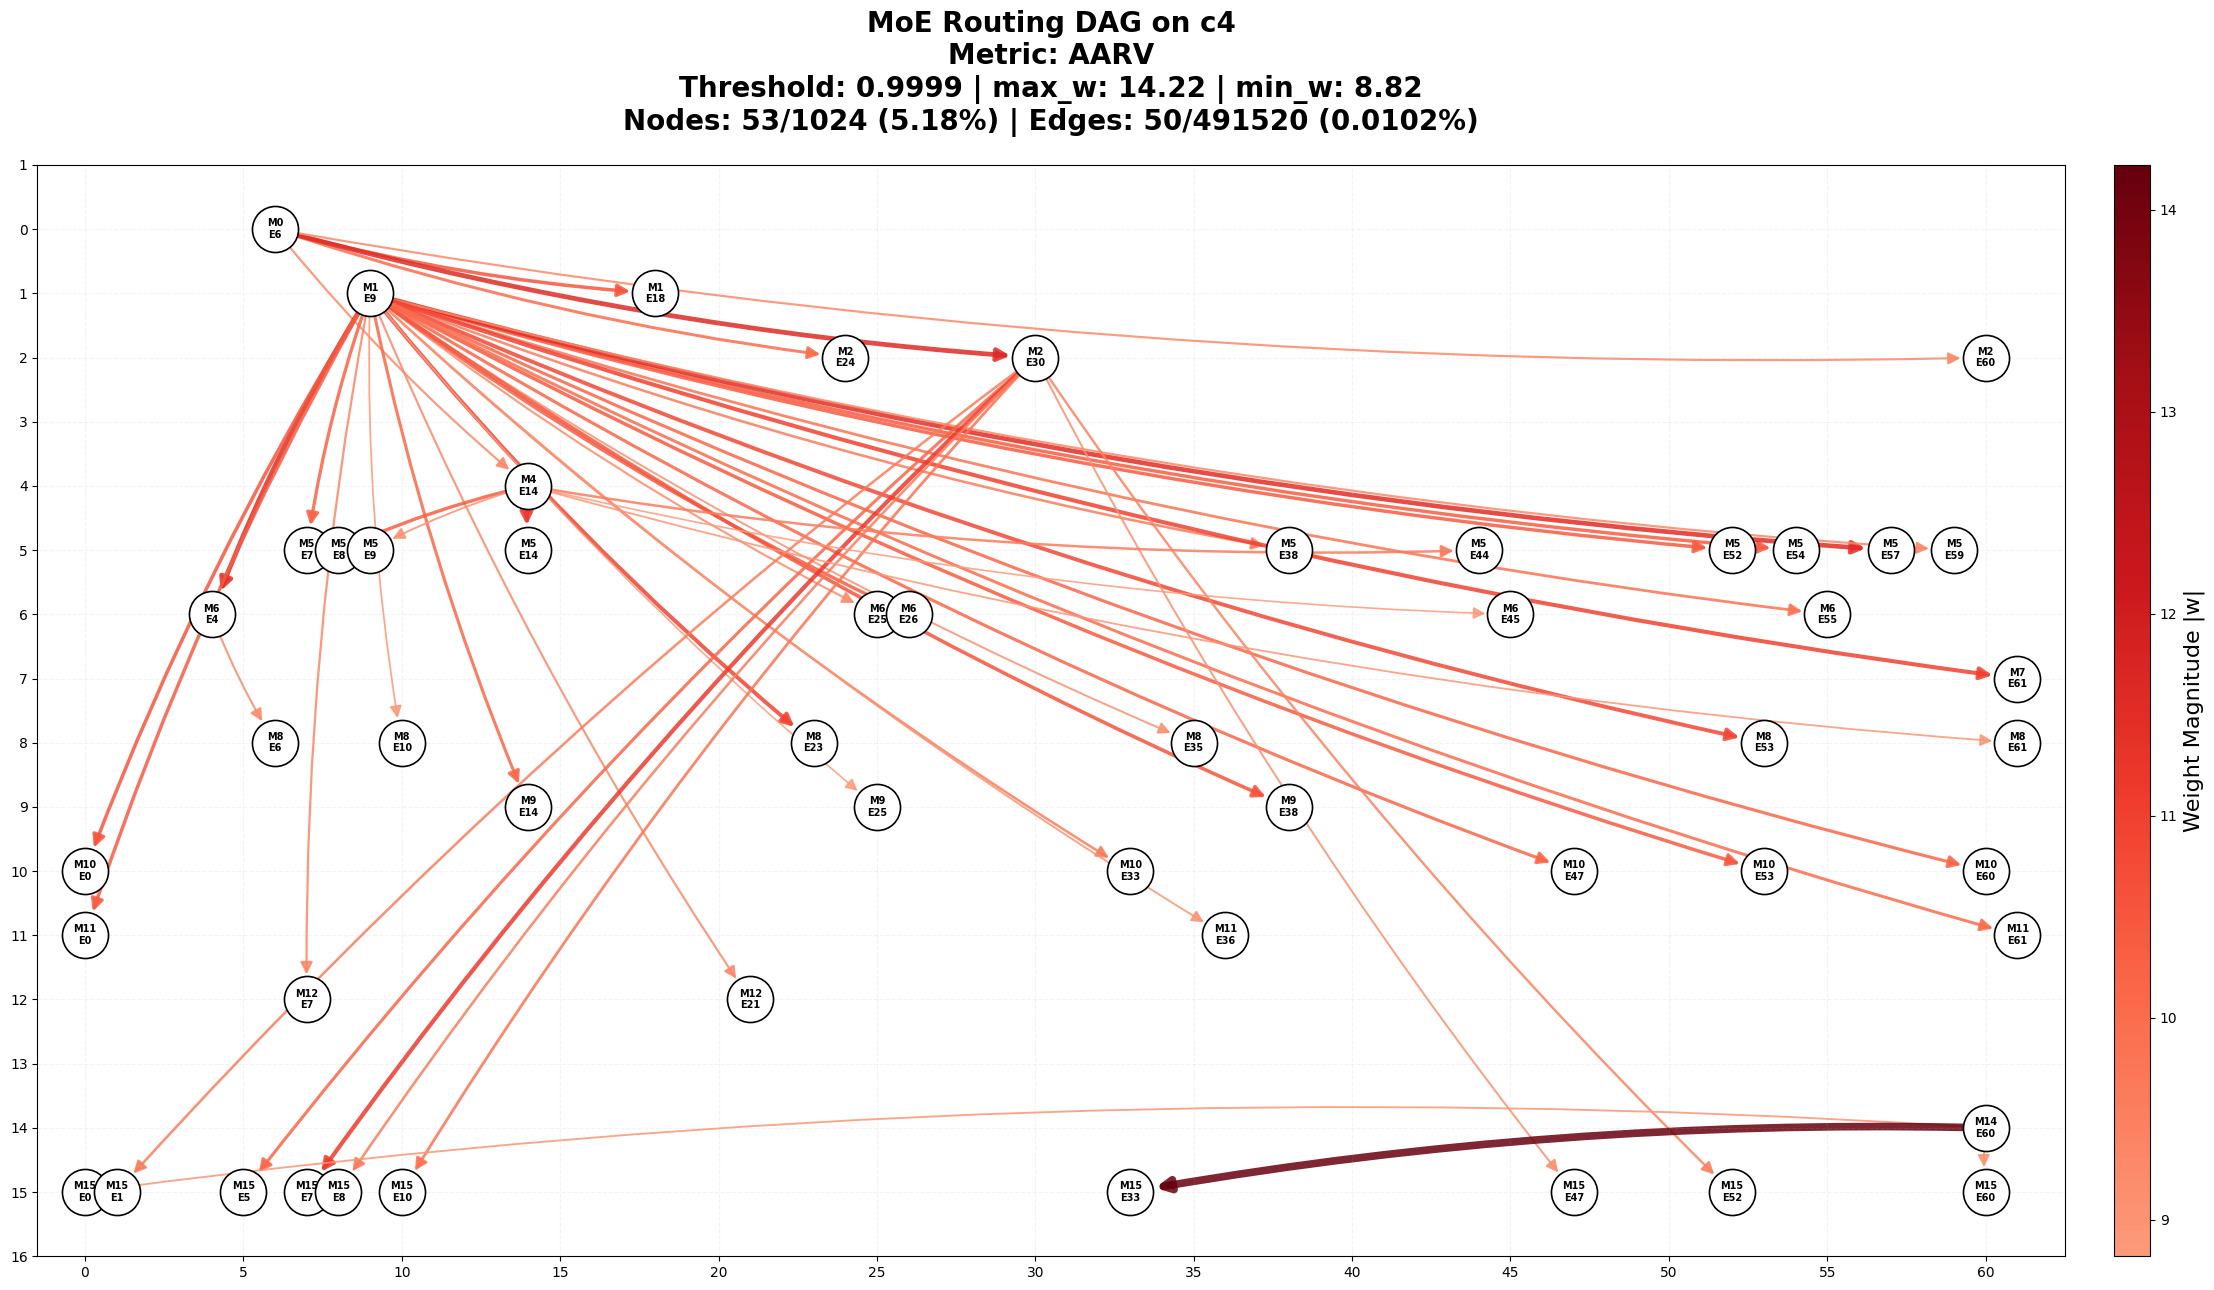

'\nplt.plot(x, y, marker=\'o\', linestyle=\'-\', color=\'b\')\nplt.xlabel("Threshold")\nplt.ylabel("Max Path Length")\nplt.grid(True)\nplt.show()\n'

In [ ]:
target = "AARV" # 'APS', 'ANS', 'AVG', 'VAR', 'AARV'
dataset = "c4" # "c4", "math", "code"
n_prompts = 10_000
art_dir = os.path.join(config["result_path"], "circuits")
path = os.path.join(art_dir, f"dag_{dataset}.pt")
dag = torch.load(path, map_location='cpu')

quantiles = (1 - torch.logspace(-1, -4, steps=50)).tolist()

threshold_map = get_thresholds(dag=dag, target=target, quantiles=quantiles)
i = 0
num_thresholds = len(threshold_map)
"""
x, y = [], []
for q, t in threshold_map.items():
    i += 1
    g = tresholding_routing_graph(dag=dag, target=target, threshold=t)
    path, length, nums = max_path_length(g)
    print(f"{i}: quantile: {q}, threshold: {t:.3f}, max path length: {length}, occurences: {nums},  path: {path_as_str(path)}.")
    x.append(t)
    y.append(length)
    if i == num_thresholds: 
        show_enhanced_layered_graph(g, q, target, dataset)
"""
g = tresholding_routing_graph(dag, target, threshold_map[quantiles[-1]])
show_enhanced_layered_graph(g, quantiles[-1], target, dataset, n_prompts) 
    
"""
plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.xlabel("Threshold")
plt.ylabel("Max Path Length")
plt.grid(True)
plt.show()
""" 